In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import ast
from pathlib import Path

In [13]:
df = pd.read_csv('tracks.csv')
print(f"Shape: {df.shape}\n")

df.head()

Shape: (586672, 20)



,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,35iwgR4jXetI318WEWsa1Q,Carve,6,126903,0,['Uli'],['45tIt06XoI0Iio4LBEVpls'],1922-02-22,0.645,0.4450,0,-13.338,1,0.4510,0.674,0.7440,0.151,0.127,104.851,3
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98200,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.695,0.2630,0,-22.136,1,0.9570,0.797,0.0000,0.148,0.655,102.009,1
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,181640,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.434,0.1770,1,-21.180,1,0.0512,0.994,0.0218,0.212,0.457,130.418,5
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,176907,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.321,0.0946,7,-27.961,1,0.0504,0.995,0.9180,0.104,0.397,169.980,3
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,163080,0,['Dick Haymes'],['3BiJGZsyX9sJchTqcSA7Su'],1922,0.402,0.1580,3,-16.900,0,0.0390,0.989,0.1300,0.311,0.196,103.220,4


In [14]:
df.drop(columns=['id', 'name', 'artists', 'id_artists'], inplace=True)

In [15]:
df.isnull().sum()

popularity          0
duration_ms         0
explicit            0
release_date        0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
dtype: int64

In [16]:
# Identify useful audio features
audio_features = [
    'acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'loudness',
    'speechiness', 'valence', 'tempo', 'duration_ms', 'key', 'mode', 'time_signature'
    # Add or remove features as needed based on EDA
 ]
df_features = df[audio_features].copy()
df_features.head()

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,valence,tempo,duration_ms,key,mode,time_signature
0,0.674,0.645,0.4450,0.7440,0.151,-13.338,0.4510,0.127,104.851,126903,0,1,3
1,0.797,0.695,0.2630,0.0000,0.148,-22.136,0.9570,0.655,102.009,98200,0,1,1
2,0.994,0.434,0.1770,0.0218,0.212,-21.180,0.0512,0.457,130.418,181640,1,1,5
3,0.995,0.321,0.0946,0.9180,0.104,-27.961,0.0504,0.397,169.980,176907,7,1,3
4,0.989,0.402,0.1580,0.1300,0.311,-16.900,0.0390,0.196,103.220,163080,3,0,4


In [17]:
# Scale / normalize features
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_features), columns=audio_features)
df_scaled.head()

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,valence,tempo,duration_ms,key,mode,time_signature
0,0.642528,0.490096,-0.385182,2.362779,-0.341434,-0.615393,1.924128,-1.650527,-0.457392,-0.815233,-1.483654,0.719665,-1.845842
1,0.995129,0.791115,-1.107625,-0.425120,-0.357710,-2.344110,4.736917,0.398600,-0.552876,-1.042088,-1.483654,0.719665,-6.072724
2,1.559864,-0.780204,-1.449000,-0.343432,-0.010498,-2.156266,-0.298309,-0.369823,0.401596,-0.382618,-1.199517,0.719665,2.381040
3,1.562730,-1.460507,-1.776084,3.014787,-0.596418,-3.488663,-0.302756,-0.602678,1.730782,-0.420026,0.505310,0.719665,-1.845842
4,1.545530,-0.972856,-1.524420,0.062013,0.526596,-1.315289,-0.366127,-1.382743,-0.512190,-0.529308,-0.631241,-1.389536,0.267599


In [18]:
# Create final feature matrix
X = df_scaled.copy()
X.head()

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,valence,tempo,duration_ms,key,mode,time_signature
0,0.642528,0.490096,-0.385182,2.362779,-0.341434,-0.615393,1.924128,-1.650527,-0.457392,-0.815233,-1.483654,0.719665,-1.845842
1,0.995129,0.791115,-1.107625,-0.425120,-0.357710,-2.344110,4.736917,0.398600,-0.552876,-1.042088,-1.483654,0.719665,-6.072724
2,1.559864,-0.780204,-1.449000,-0.343432,-0.010498,-2.156266,-0.298309,-0.369823,0.401596,-0.382618,-1.199517,0.719665,2.381040
3,1.562730,-1.460507,-1.776084,3.014787,-0.596418,-3.488663,-0.302756,-0.602678,1.730782,-0.420026,0.505310,0.719665,-1.845842
4,1.545530,-0.972856,-1.524420,0.062013,0.526596,-1.315289,-0.366127,-1.382743,-0.512190,-0.529308,-0.631241,-1.389536,0.267599


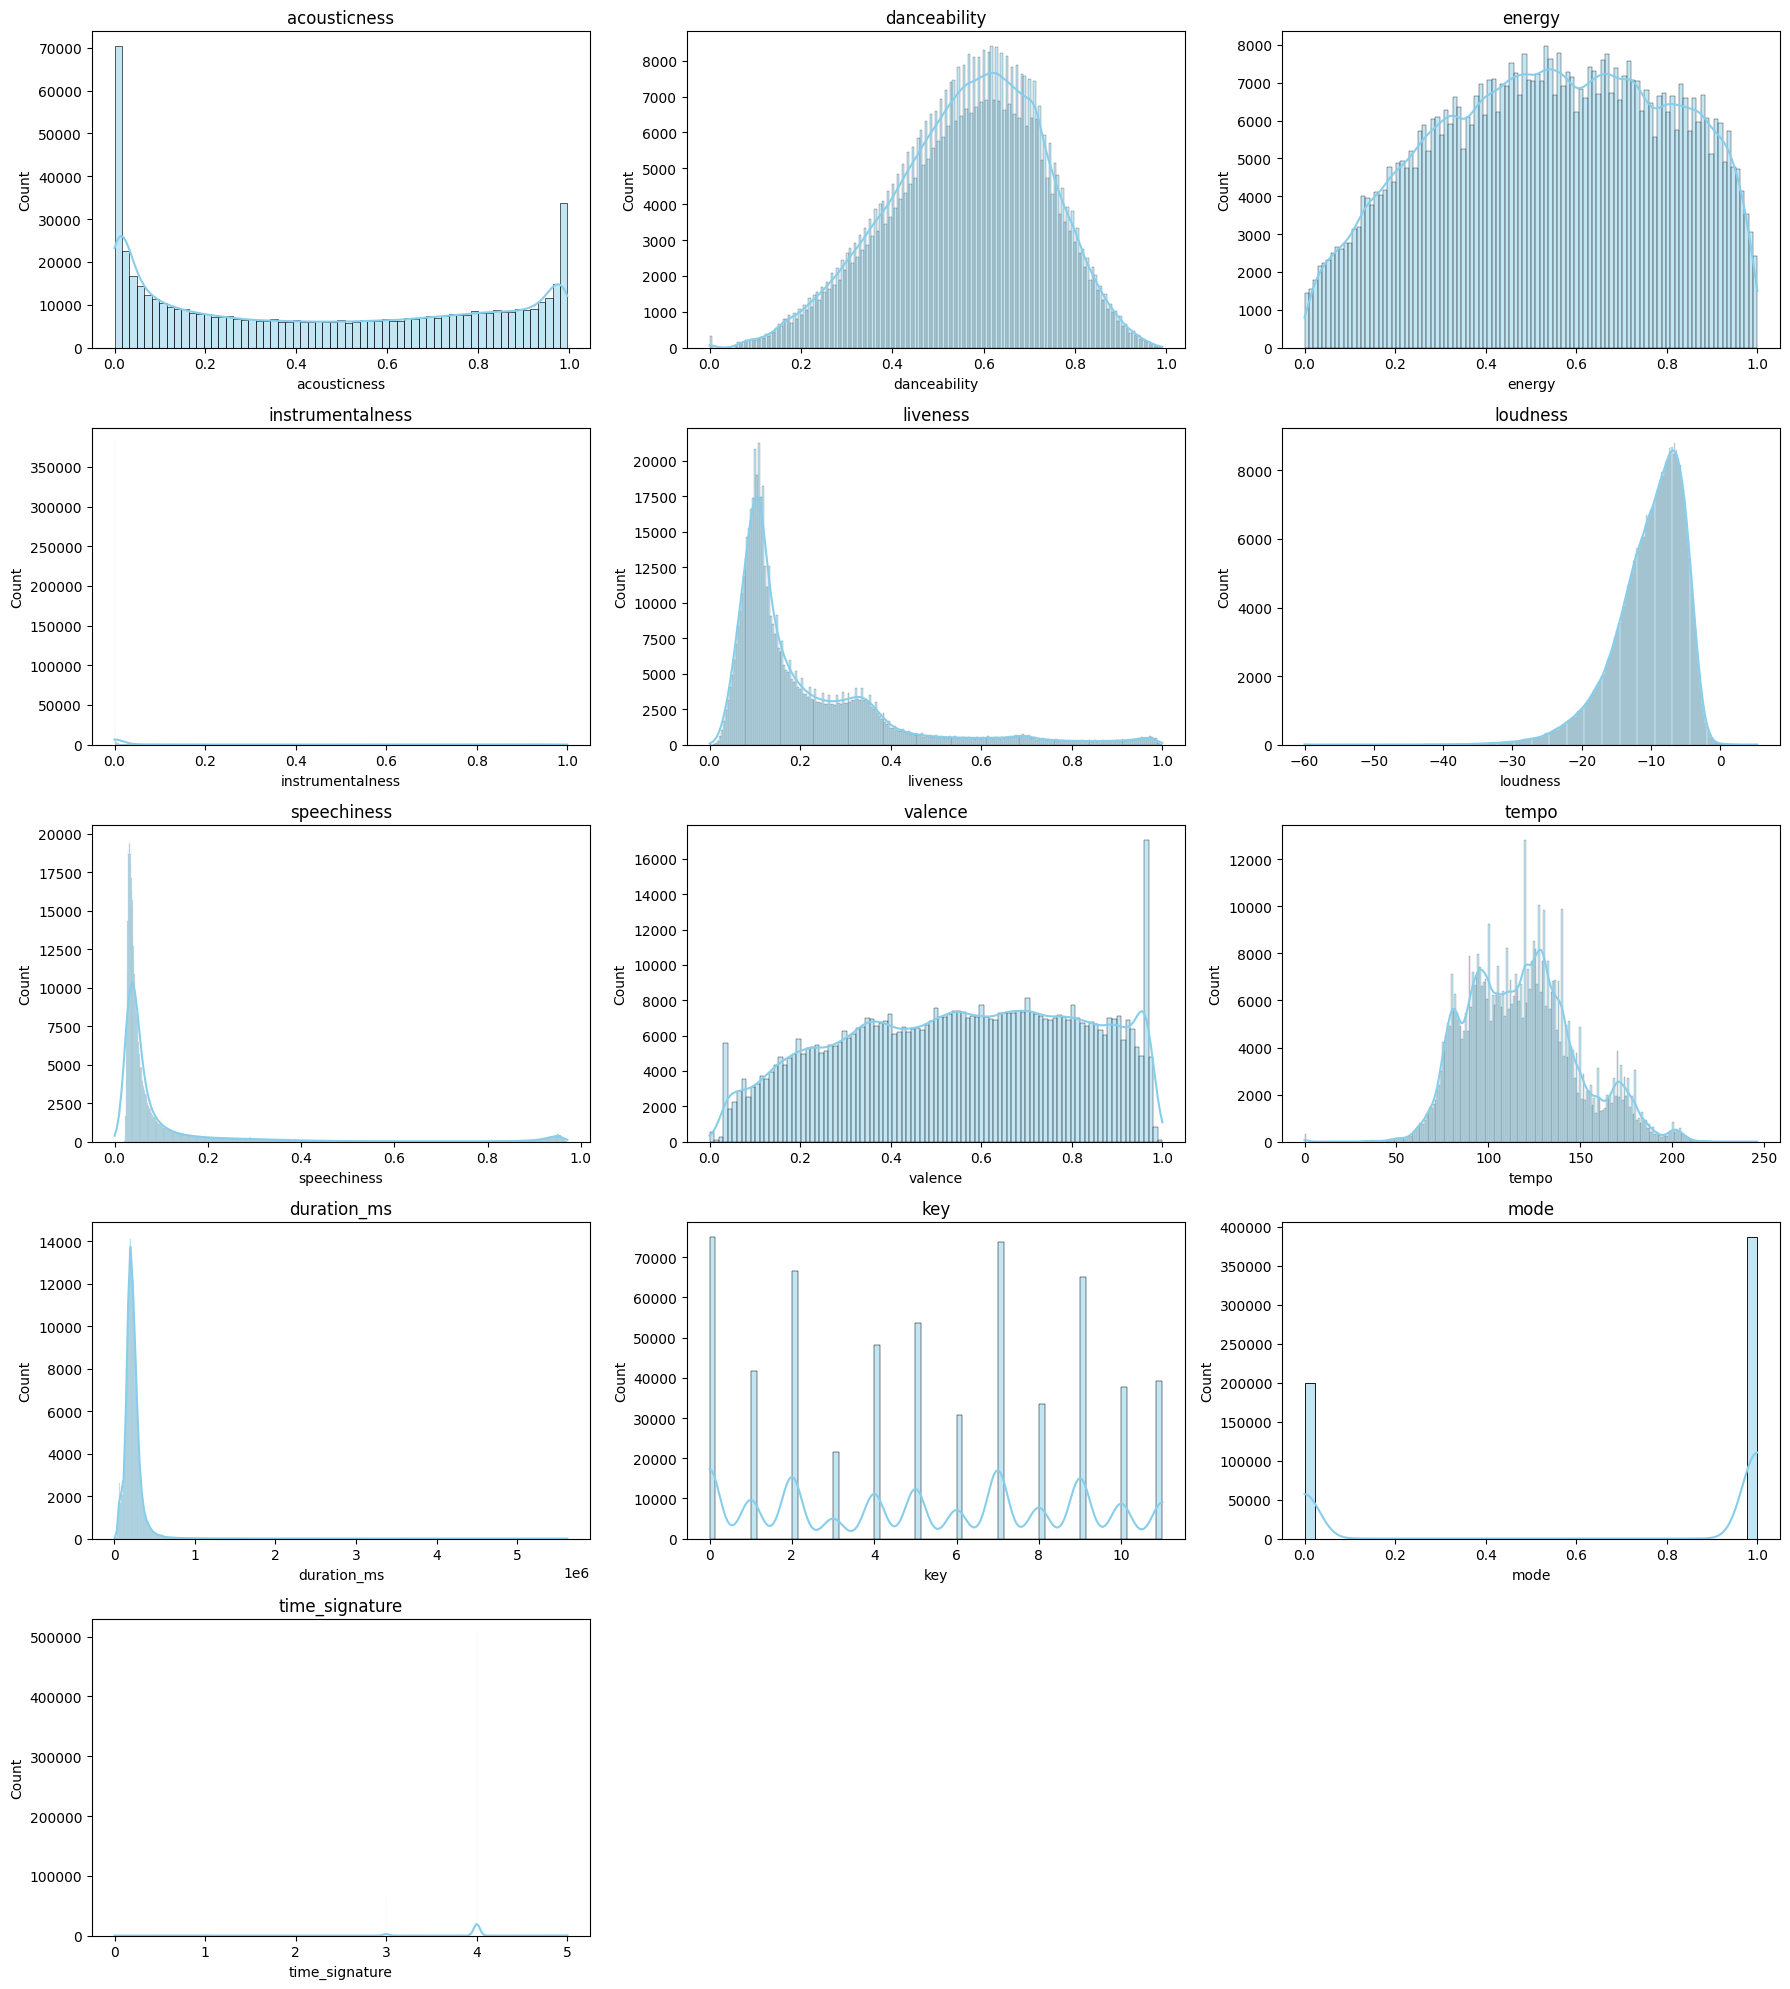

In [21]:
# Distribution plots for audio features
n_features = len(audio_features)
n_rows = int(np.ceil(n_features / 3))
fig, axes = plt.subplots(nrows=n_rows, ncols=3, figsize=(18, 4 * n_rows))
axes = axes.flatten()
for i, feature in enumerate(audio_features):
    sns.histplot(df[feature], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(feature)
# Hide any unused subplots
for j in range(n_features, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()